In [64]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.feature_selection import chi2

# For better plot style
plt.style.use('ggplot')

In [65]:
#  Load Dataset

wine = load_wine()

X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name="target")

df = X.copy()
df["target"] = y

print("Dataset Loaded Successfully ")
print()

Dataset Loaded Successfully 



In [66]:
# EDA

print("Shape of Dataset:", df.shape)

Shape of Dataset: (178, 14)


In [67]:
print("\nFirst 5 Rows:")
print(df.head())


First 5 Rows:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  targe

In [68]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    flo

In [69]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.000000   
max     14.830000    5.800000    3.230000          30.000000  162.000000   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count     178.000000  178.000000            178.000000       178.000000   
mean        2.295112    2.029270              0.361854         1.590899   
std         0.625851    0.998859              0.124453         0.572

In [70]:
print("\nClass Distribution:")
print(df["target"].value_counts())


Class Distribution:
target
1    71
0    59
2    48
Name: count, dtype: int64


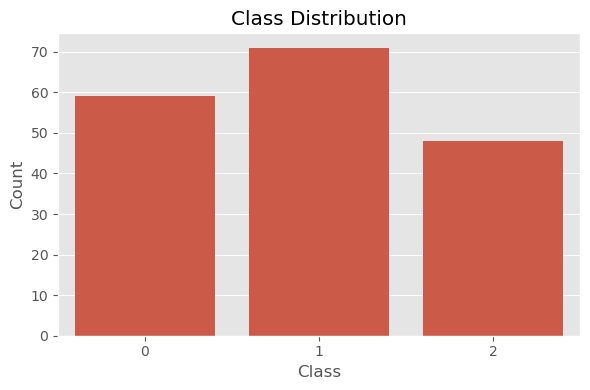

In [71]:
# Plot Class Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="target", data=df)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


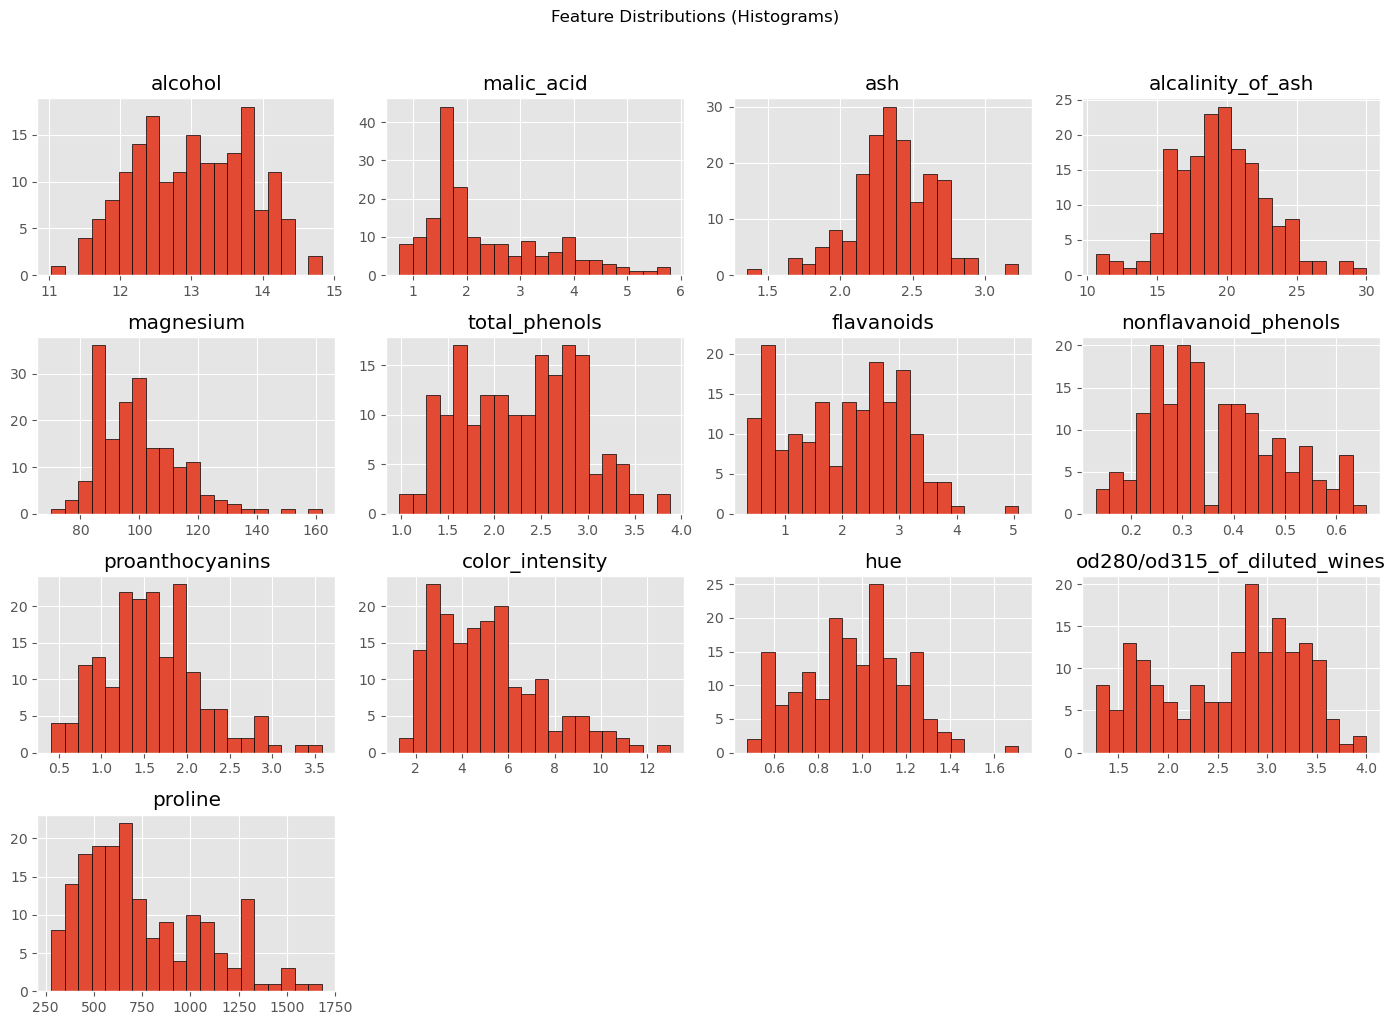

In [72]:
#  Feature Distributions (Histograms)

df.drop("target", axis=1).hist(
    figsize=(14,10),
    bins=20,
    edgecolor="black"
)
plt.suptitle("Feature Distributions (Histograms)", y=1.02)
plt.tight_layout()
plt.show()

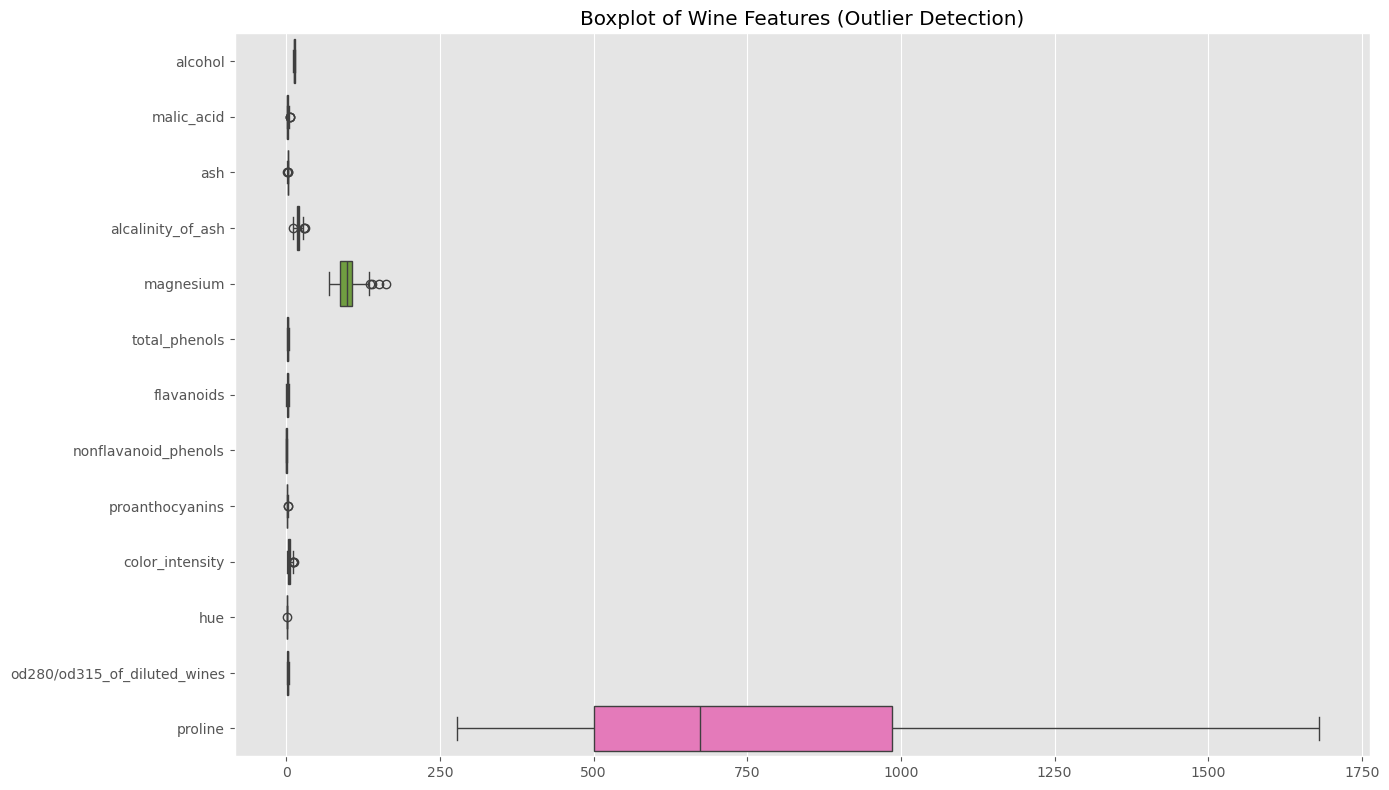

In [73]:
#  Boxplots (Outlier Detection) - All Features

plt.figure(figsize=(14,8))
sns.boxplot(
    data=df.drop("target", axis=1),
    orient="h"
)
plt.title("Boxplot of Wine Features (Outlier Detection)")
plt.tight_layout()
plt.show()

In [ ]:
#  Outlier Count Table   IQR Method


outlier_counts = {}

for col in X.columns:
    
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = X[(X[col] < lower_bound) | (X[col] > upper_bound)]
    
    outlier_counts[col] = len(outliers)

outlier_table = pd.DataFrame.from_dict(
    outlier_counts,
    orient="index",
    columns=["Outlier Count"]
)

outlier_table = outlier_table.sort_values(
    by="Outlier Count",
    ascending=False
)

print("\nOutlier Count Table (IQR Method):")
display(outlier_table)


Outlier Count Table (IQR Method):


,Outlier Count
alcalinity_of_ash,4
magnesium,4
color_intensity,4
malic_acid,3
ash,3
proanthocyanins,2
hue,1
alcohol,0
total_phenols,0
flavanoids,0


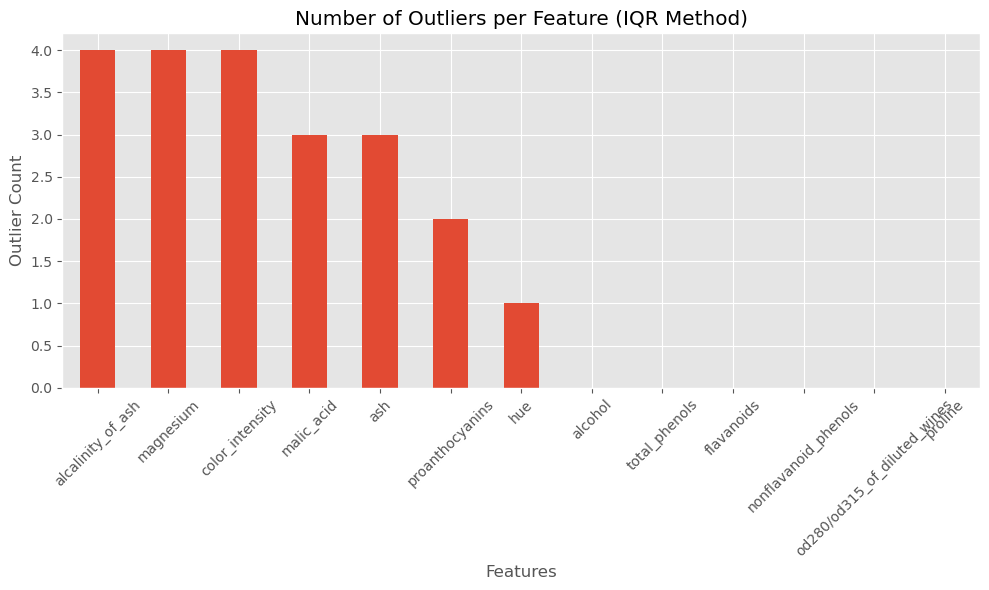

In [75]:
plt.figure(figsize=(10,6))
outlier_table["Outlier Count"].plot(kind="bar")
plt.title("Number of Outliers per Feature (IQR Method)")
plt.ylabel("Outlier Count")
plt.xlabel("Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

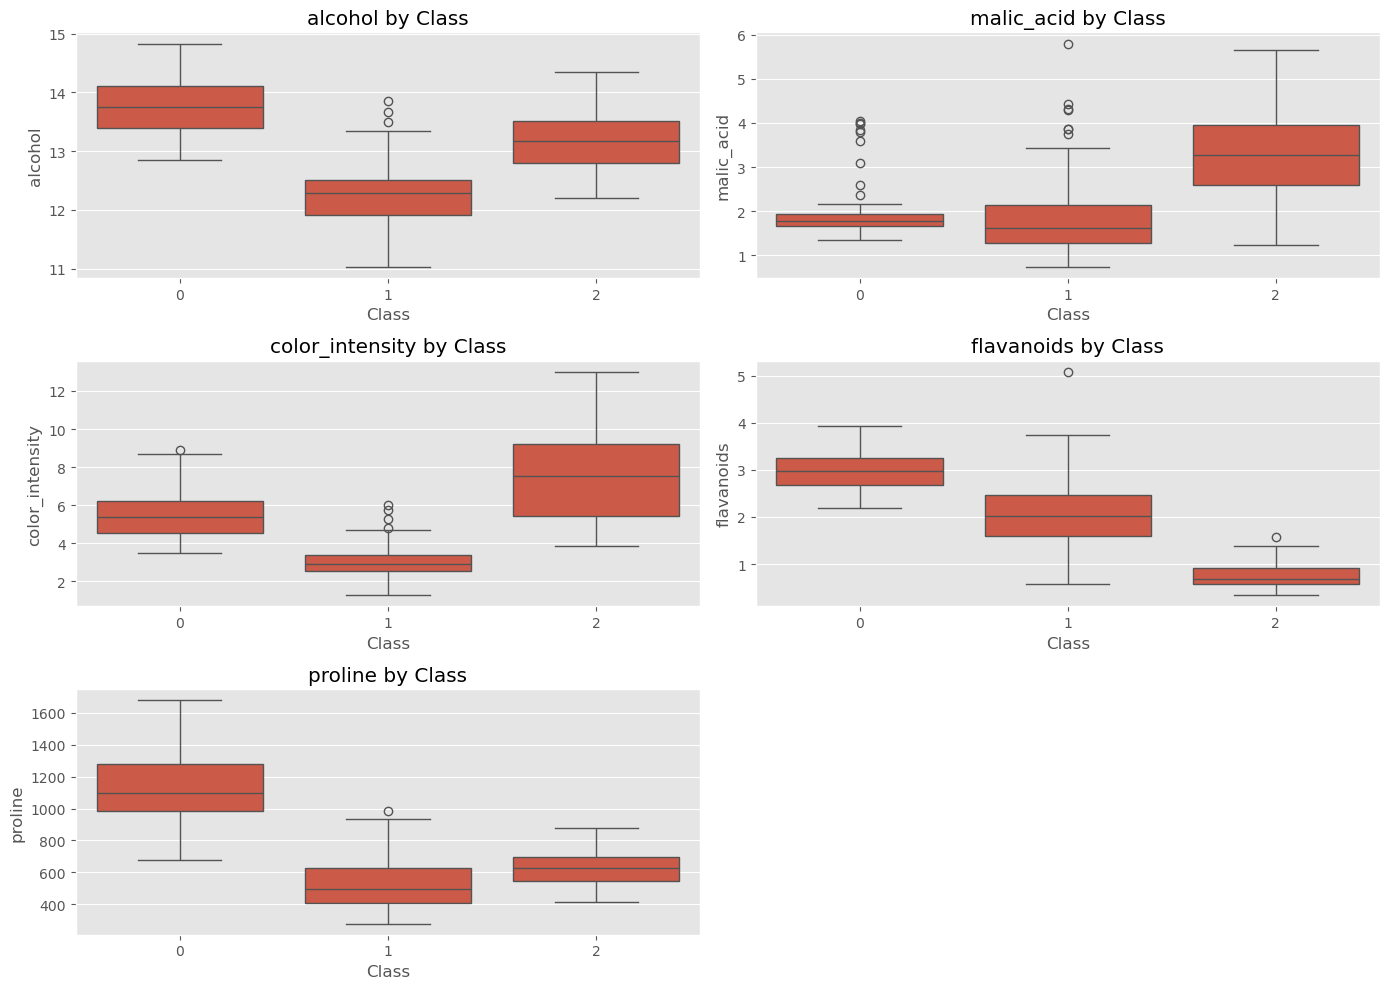

In [76]:
#  Class-wise Boxplots   Selected Features

selected_features = ["alcohol", "malic_acid", "color_intensity", "flavanoids", "proline"]

plt.figure(figsize=(14,10))
for i, feat in enumerate(selected_features, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(x="target", y=feat, data=df)
    plt.title(f"{feat} by Class")
    plt.xlabel("Class")
    plt.ylabel(feat)

plt.tight_layout()
plt.show()

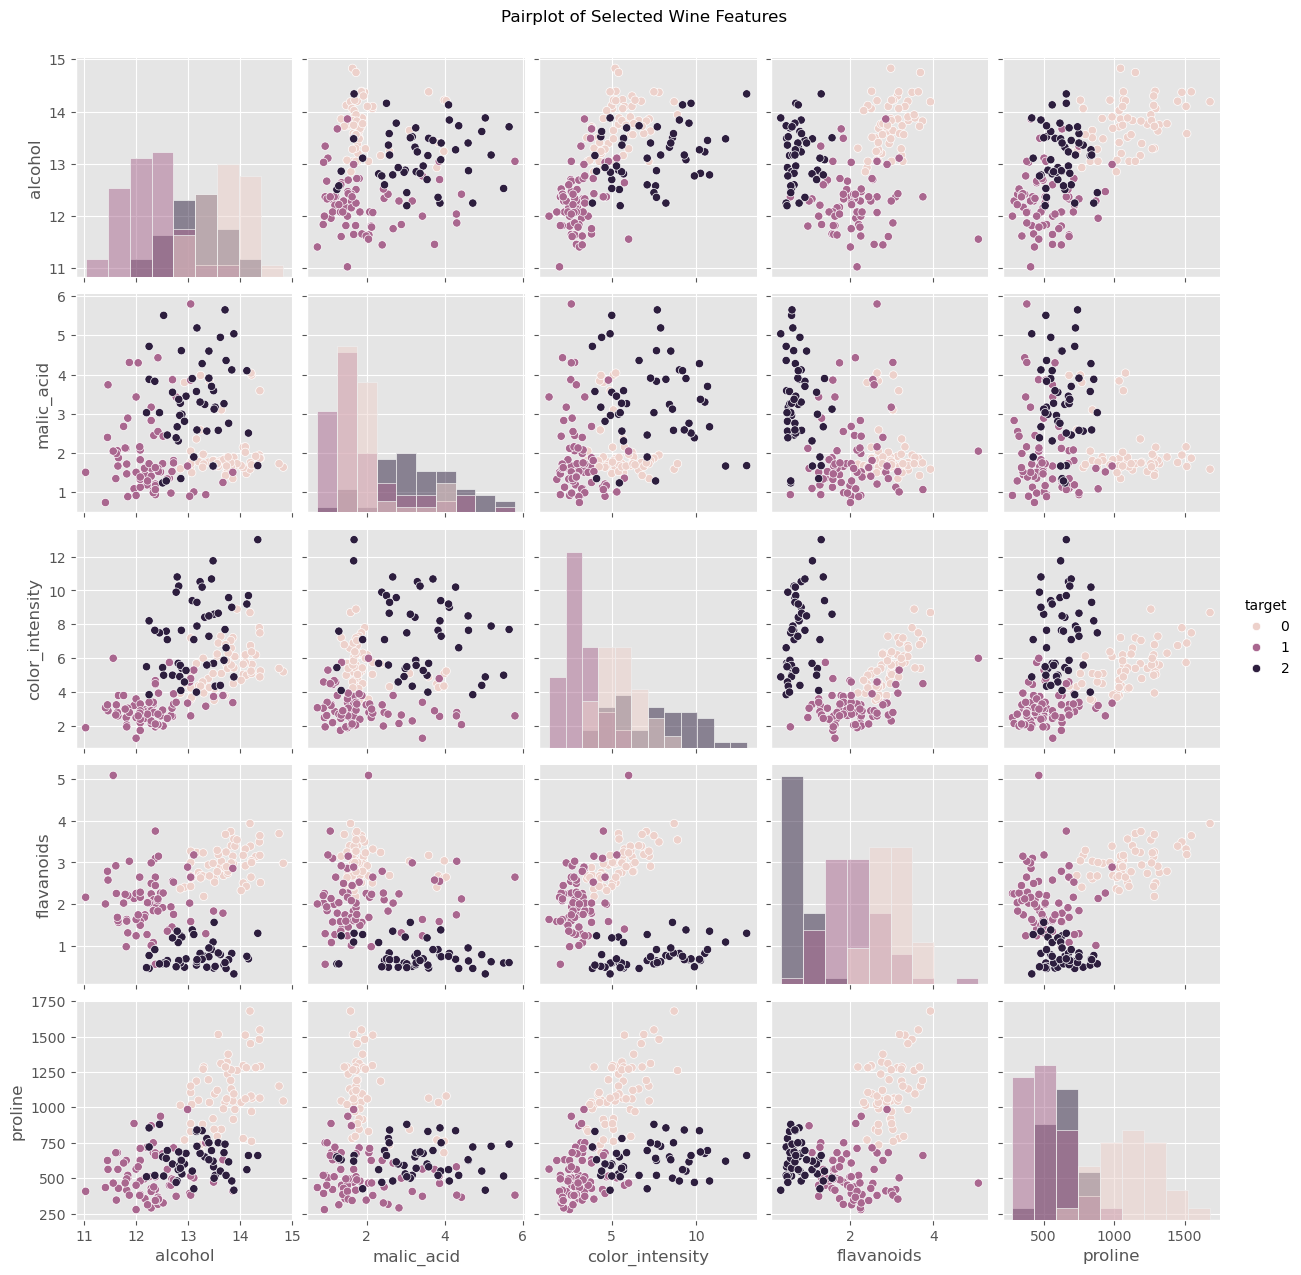

In [77]:
# Pairplot    Selected Features

sns.pairplot(
    df[selected_features + ["target"]],
    hue="target",
    diag_kind="hist"
)
plt.suptitle("Pairplot of Selected Wine Features", y=1.02)
plt.show()

In [78]:
# Data Cleaning Checks

print("\nMissing Values Check:")
print(df.isnull().sum())


Missing Values Check:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64


In [79]:
print("\nDuplicate Rows Check:")
print("Number of duplicates:", df.duplicated().sum())


Duplicate Rows Check:
Number of duplicates: 0


In [80]:
print("\nConclusion:")
print(" Dataset contains NO missing values.")
print(" Dataset contains NO duplicate rows.")


Conclusion:
 Dataset contains NO missing values.
 Dataset contains NO duplicate rows.


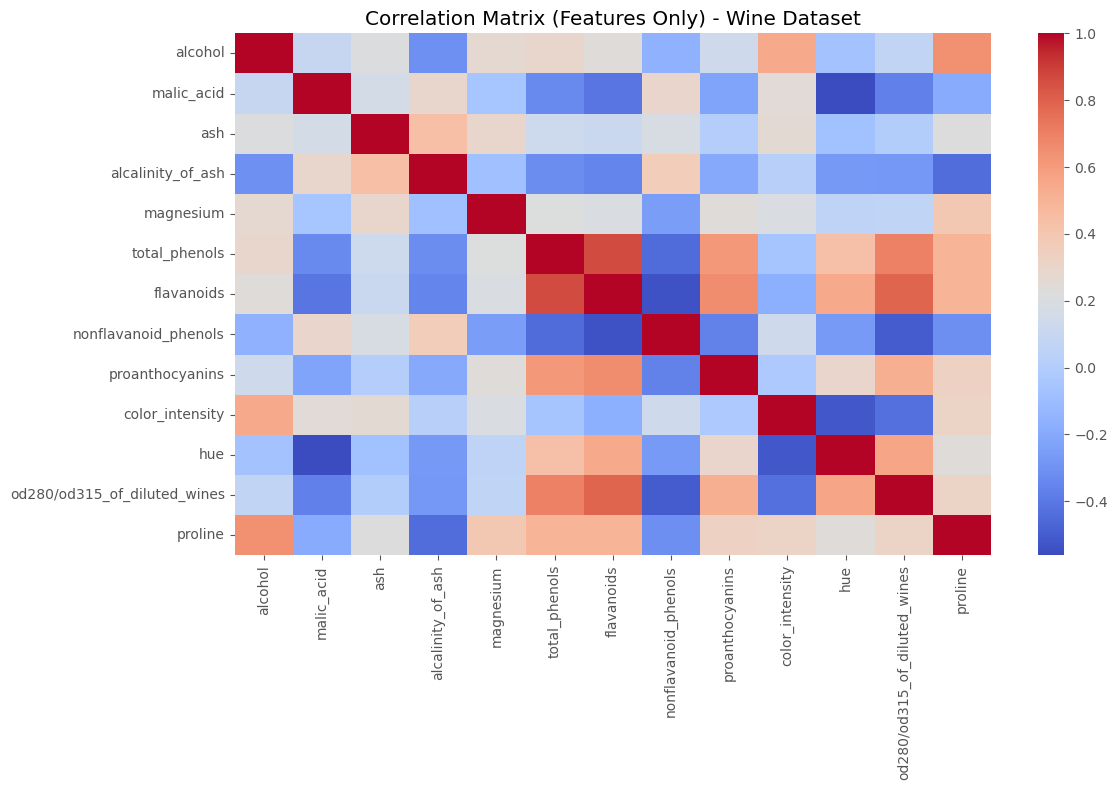

In [84]:
# Correlation Heatmap 

plt.figure(figsize=(12,8))
sns.heatmap(X.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Matrix (Features Only) - Wine Dataset")
plt.tight_layout()
plt.show()


Pearson Correlation Feature Ranking:

Pearson Ranking:


flavanoids                      0.847498
od280/od315_of_diluted_wines    0.788230
total_phenols                   0.719163
proline                         0.633717
hue                             0.617369
alcalinity_of_ash               0.517859
proanthocyanins                 0.499130
nonflavanoid_phenols            0.489109
malic_acid                      0.437776
alcohol                         0.328222
color_intensity                 0.265668
magnesium                       0.209179
ash                             0.049643
dtype: float64

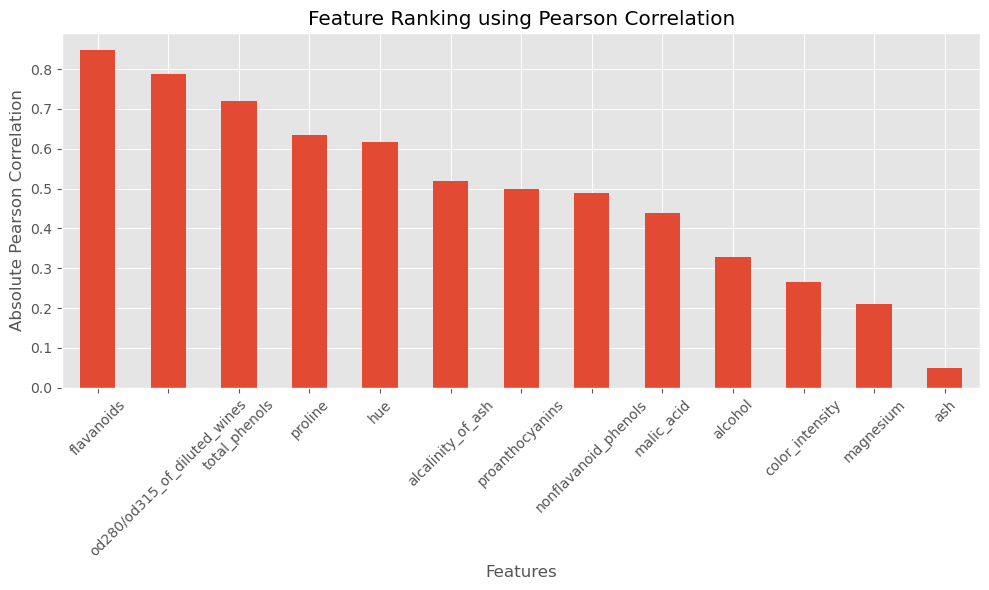

In [85]:
# Pearson Correlation Feature Ranking

print("\nPearson Correlation Feature Ranking:")

pearson_scores = {}

for col in X.columns:
    corr_value = X[col].corr(y)
    pearson_scores[col] = abs(corr_value)

pearson_ranking = pd.Series(pearson_scores).sort_values(ascending=False)

print("\nPearson Ranking:")
display(pearson_ranking)

# Plot Pearson Ranking
plt.figure(figsize=(10,6))
pearson_ranking.plot(kind='bar')
plt.title("Feature Ranking using Pearson Correlation")
plt.xlabel("Features")
plt.ylabel("Absolute Pearson Correlation")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [86]:
# Chi-Square Feature Ranking 

class ChiSquaredFeatureSelector:
    """
    Calculates Chi-Square scores manually for each feature
    after discretizing continuous values into bins.
    """

    def __init__(self, target_col=None, bins=5):
        self.target_col = target_col
        self.bins = bins
        self.chi2_scores_ = {}

    def _chi_squared_stat(self, contingency_table):
        observed = contingency_table.values
        row_totals = observed.sum(axis=1)
        col_totals = observed.sum(axis=0)
        total = observed.sum()

        expected = np.outer(row_totals, col_totals) / total
        chi_squared = np.sum((observed - expected) ** 2 / expected)

        return chi_squared

    def fit(self, df):
        if self.target_col is None:
            raise ValueError("target_col must be provided.")

        y = df[self.target_col]

        for col in df.columns:
            if col == self.target_col:
                continue

            # Discretize continuous feature into bins
            binned_feature = pd.cut(df[col], bins=self.bins, labels=False)

            # Create contingency table
            cont_table = pd.crosstab(binned_feature, y)

            # Compute chi-square score manually
            chi_score = self._chi_squared_stat(cont_table)
            self.chi2_scores_[col] = chi_score

        return self


Chi-Square Ranking:


flavanoids                      202.892976
color_intensity                 151.546493
od280/od315_of_diluted_wines    146.909004
proline                         145.127358
hue                             120.304286
alcohol                         116.650265
total_phenols                   109.784968
magnesium                        66.765070
malic_acid                       62.274397
alcalinity_of_ash                61.553153
proanthocyanins                  58.890123
nonflavanoid_phenols             56.097105
ash                              27.411598
dtype: float64

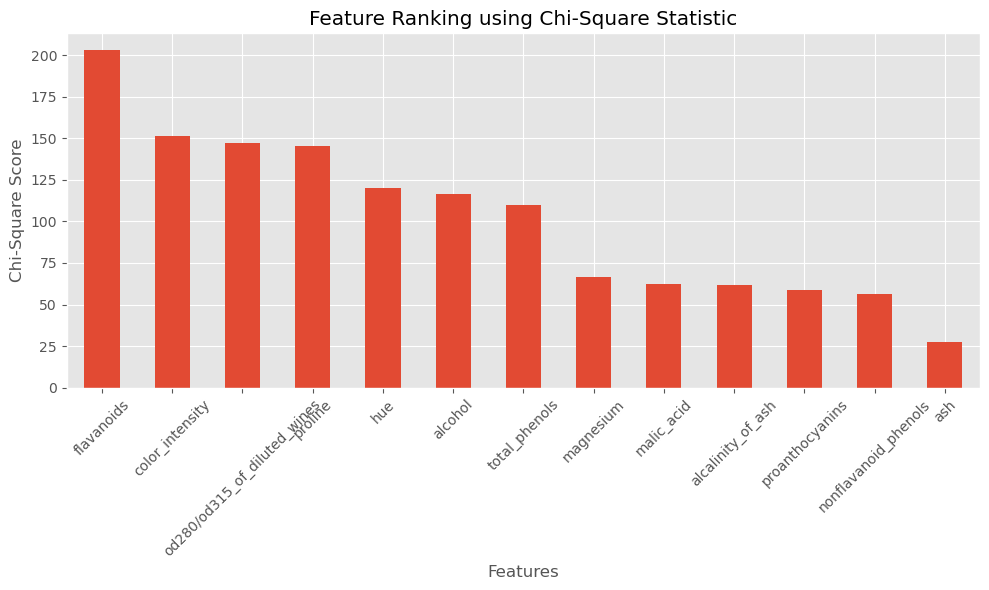

In [87]:
# Apply Chi-Square Selector

chi_df = df.copy()

chi_selector = ChiSquaredFeatureSelector(target_col='target', bins=5)
chi_selector.fit(chi_df)

chi_ranking = pd.Series(chi_selector.chi2_scores_).sort_values(ascending=False)

print("\nChi-Square Ranking:")
display(chi_ranking)

# Plot Chi-Square Ranking
plt.figure(figsize=(10,6))
chi_ranking.plot(kind='bar')
plt.title("Feature Ranking using Chi-Square Statistic")
plt.xlabel("Features")
plt.ylabel("Chi-Square Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [89]:
# Feature Comparison

comparison_df = pd.DataFrame({
    "Pearson Score": pearson_ranking,
    "Chi-Square Score": chi_ranking
})

comparison_df["Pearson Rank"] = comparison_df["Pearson Score"].rank(ascending=False, method="dense").astype(int)
comparison_df["Chi-Square Rank"] = comparison_df["Chi-Square Score"].rank(ascending=False, method="dense").astype(int)

comparison_df = comparison_df.sort_values(by="Pearson Rank")

print("\nFeature Comparison Table:")
display(comparison_df)


Feature Comparison Table:


,Pearson Score,Chi-Square Score,Pearson Rank,Chi-Square Rank
flavanoids,0.847498,202.892976,1,1
od280/od315_of_diluted_wines,0.788230,146.909004,2,3
total_phenols,0.719163,109.784968,3,7
proline,0.633717,145.127358,4,4
hue,0.617369,120.304286,5,5
alcalinity_of_ash,0.517859,61.553153,6,10
proanthocyanins,0.499130,58.890123,7,11
nonflavanoid_phenols,0.489109,56.097105,8,12
malic_acid,0.437776,62.274397,9,9
alcohol,0.328222,116.650265,10,6


In [90]:
#  Top-K Features

k = 5

top_k_pearson = pearson_ranking.head(k)
top_k_chi = chi_ranking.head(k)

print(f"\nTop {k} Features based on Pearson Correlation:")
print(top_k_pearson)

print(f"\nTop {k} Features based on Chi-Square:")
display(top_k_chi)


Top 5 Features based on Pearson Correlation:
flavanoids                      0.847498
od280/od315_of_diluted_wines    0.788230
total_phenols                   0.719163
proline                         0.633717
hue                             0.617369
dtype: float64

Top 5 Features based on Chi-Square:


flavanoids                      202.892976
color_intensity                 151.546493
od280/od315_of_diluted_wines    146.909004
proline                         145.127358
hue                             120.304286
dtype: float64

In [ ]:
# Save Rankings 
comparison_df.to_csv("feature_ranking.csv")


Spearman Rank Correlation Feature Ranking:

Spearman Ranking:
flavanoids                      0.854908
od280/od315_of_diluted_wines    0.743787
total_phenols                   0.726544
hue                             0.616570
proline                         0.576383
proanthocyanins                 0.570648
alcalinity_of_ash               0.569792
nonflavanoid_phenols            0.474205
alcohol                         0.354167
malic_acid                      0.346913
magnesium                       0.250498
color_intensity                 0.131170
ash                             0.053988
dtype: float64


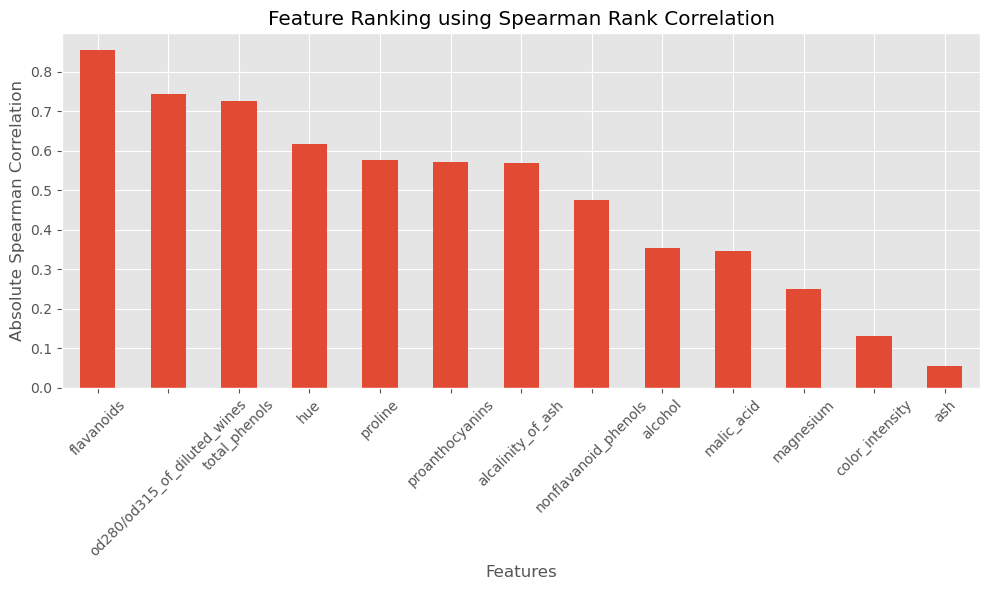

In [91]:
# Spearman Rank Correlation


print("\nSpearman Rank Correlation Feature Ranking:")

spearman_scores = {}

for col in X.columns:
    corr_value = X[col].corr(y, method="spearman")
    spearman_scores[col] = abs(corr_value)

spearman_ranking = pd.Series(spearman_scores).sort_values(ascending=False)

print("\nSpearman Ranking:")
print(spearman_ranking)

# Plot Spearman Ranking
plt.figure(figsize=(10,6))
spearman_ranking.plot(kind='bar')
plt.title("Feature Ranking using Spearman Rank Correlation")
plt.xlabel("Features")
plt.ylabel("Absolute Spearman Correlation")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [92]:

# Gini Index Feature Ranking


class GiniFeatureSelector:


    def __init__(self, k, target_col, bins=5):
        self.k = k
        self.target_col = target_col
        self.bins = bins
        self.gini_scores_ = {}
        self.selected_features_ = []

    def _gini(self, y):
        counts = np.bincount(y)
        probabilities = counts / len(y)
        return 1 - np.sum(probabilities ** 2)

    def _weighted_gini(self, X_col, y):
        unique_values, counts = np.unique(X_col, return_counts=True)
        weighted_gini = 0

        for value, count in zip(unique_values, counts):
            y_subset = y[X_col == value]
            weight = count / len(y)
            weighted_gini += weight * self._gini(y_subset)

        return weighted_gini

    def _calculate_gini_scores(self, df):
        y = df[self.target_col].values
        gini_scores = {}

        for col in df.columns:
            if col == self.target_col:
                continue

            # Convert continuous feature into bins
            binned_feature = pd.cut(df[col], bins=self.bins, labels=False)

            X_col = binned_feature.values
            gini_scores[col] = self._weighted_gini(X_col, y)

        return gini_scores

    def fit(self, df):
        if self.target_col is None:
            raise ValueError("target_col must be provided.")

        self.gini_scores_ = self._calculate_gini_scores(df)

        # Lower Gini = better feature
        sorted_features = sorted(
            self.gini_scores_,
            key=self.gini_scores_.get
        )

        self.selected_features_ = sorted_features[:self.k]

        return self

    def transform(self, df):
        return df[self.selected_features_ + [self.target_col]]

    def fit_transform(self, df):
        return self.fit(df).transform(df)





Gini Ranking:
flavanoids                      0.297733
color_intensity                 0.365062
proline                         0.382828
od280/od315_of_diluted_wines    0.411704
alcohol                         0.423264
hue                             0.455662
total_phenols                   0.468600
magnesium                       0.523013
alcalinity_of_ash               0.550034
malic_acid                      0.552397
proanthocyanins                 0.559815
nonflavanoid_phenols            0.562133
ash                             0.603486
dtype: float64

Selected Features using Gini:
['flavanoids', 'color_intensity', 'proline', 'od280/od315_of_diluted_wines', 'alcohol']


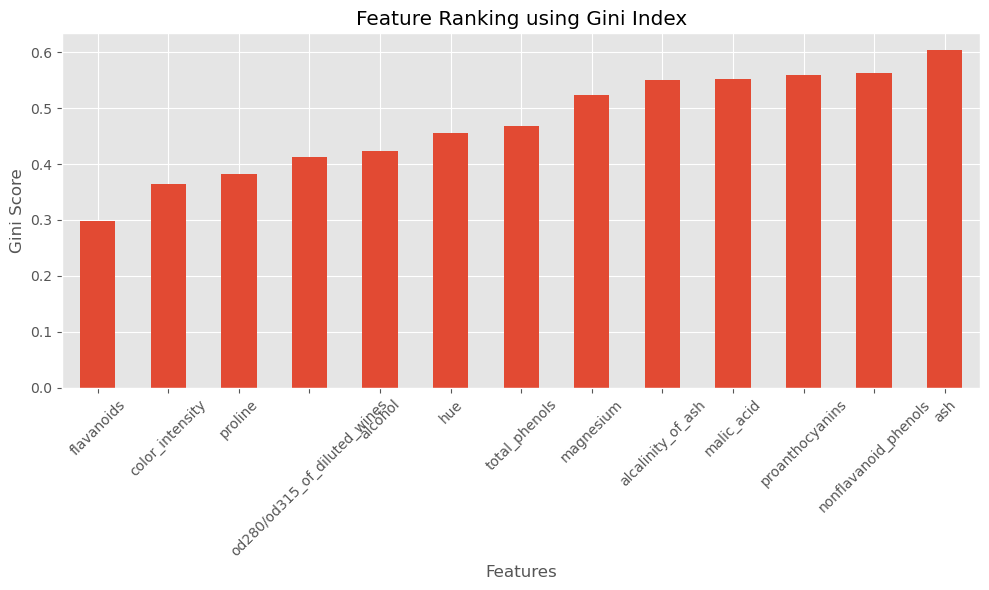

In [93]:
# Apply Gini Selector
gini_selector = GiniFeatureSelector(k=5, target_col="target", bins=5)
gini_selector.fit(df)

gini_ranking = pd.Series(gini_selector.gini_scores_).sort_values(ascending=True)

print("\nGini Ranking:")
print(gini_ranking)

print("\nSelected Features using Gini:")
print(gini_selector.selected_features_)

# Plot Gini Ranking
plt.figure(figsize=(10,6))
gini_ranking.plot(kind='bar')
plt.title("Feature Ranking using Gini Index")
plt.xlabel("Features")
plt.ylabel("Gini Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [94]:
# Feature Comparison


comparison_phase2 = pd.DataFrame({
    "Spearman Score": spearman_ranking,
    "Gini Score": gini_ranking
})

comparison_phase2["Spearman Rank"] = comparison_phase2["Spearman Score"].rank(
    ascending=False, method="dense"
).astype(int)

comparison_phase2["Gini Rank"] = comparison_phase2["Gini Score"].rank(
    ascending=True, method="dense"
).astype(int)

comparison_phase2 = comparison_phase2.sort_values(by="Spearman Rank")

print("\nPhase 2 Feature Comparison Table:")
display(comparison_phase2)


Phase 2 Feature Comparison Table:


,Spearman Score,Gini Score,Spearman Rank,Gini Rank
flavanoids,0.854908,0.297733,1,1
od280/od315_of_diluted_wines,0.743787,0.411704,2,4
total_phenols,0.726544,0.468600,3,7
hue,0.616570,0.455662,4,6
proline,0.576383,0.382828,5,3
proanthocyanins,0.570648,0.559815,6,11
alcalinity_of_ash,0.569792,0.550034,7,9
nonflavanoid_phenols,0.474205,0.562133,8,12
alcohol,0.354167,0.423264,9,5
malic_acid,0.346913,0.552397,10,10


In [95]:
# Top-K Features


k = 5

top_k_spearman = spearman_ranking.head(k)
top_k_gini = gini_ranking.head(k)

print(f"\nTop {k} Features based on Spearman Rank Correlation:")
display(top_k_spearman)

print(f"\nTop {k} Features based on Gini Index (Lower is Better):")
display(top_k_gini)



Top 5 Features based on Spearman Rank Correlation:


flavanoids                      0.854908
od280/od315_of_diluted_wines    0.743787
total_phenols                   0.726544
hue                             0.616570
proline                         0.576383
dtype: float64


Top 5 Features based on Gini Index (Lower is Better):


flavanoids                      0.297733
color_intensity                 0.365062
proline                         0.382828
od280/od315_of_diluted_wines    0.411704
alcohol                         0.423264
dtype: float64

In [ ]:
# Save Results

comparison_phase2.to_csv("phase2_feature_ranking.csv", index=True)
